## Import the essential libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
from PIL import Image
import warnings
warnings.filterwarnings('ignore')

%matplotlib inline
plt.rcParams['figure.figsize'] = (12, 8)



## Define the dataset path

In [2]:
# Project root directory
BASE_DIR = os.getcwd()

# Dataset paths
train_path = os.path.join(BASE_DIR, "dermnet", "train")
test_path = os.path.join(BASE_DIR, "dermnet", "test")


print(f"Train path exists: {os.path.exists(train_path)}")
print(f"Test path exists: {os.path.exists(test_path)}")

Train path exists: True
Test path exists: True


## Get all disease classes from train folder

In [3]:
# Get all class folders in training set
classes = [d for d in os.listdir(train_path) 
           if os.path.isdir(os.path.join(train_path, d))]

print(f"Found {len(classes)} disease classes in training set:")
print(classes[:10])  # Show first 10
print("...") if len(classes) > 10 else None

Found 23 disease classes in training set:
['Acne and Rosacea Photos', 'Actinic Keratosis Basal Cell Carcinoma and other Malignant Lesions', 'Atopic Dermatitis Photos', 'Bullous Disease Photos', 'Cellulitis Impetigo and other Bacterial Infections', 'Eczema Photos', 'Exanthems and Drug Eruptions', 'Hair Loss Photos Alopecia and other Hair Diseases', 'Herpes HPV and other STDs Photos', 'Light Diseases and Disorders of Pigmentation']
...


## Count images per class in training set

In [4]:
# Create a list to store results
train_counts = []

for class_name in sorted(classes):  # sorted for consistent ordering
    class_folder = os.path.join(train_path, class_name)

    if os.path.isdir(class_folder):
        image_files = [
            f for f in os.listdir(class_folder)
            if f.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp', '.tiff'))
        ]

        train_counts.append({
            "Class": class_name,
            "Train_Count": len(image_files)
        })

# Convert to DataFrame
train_df = pd.DataFrame(train_counts)

# Sort by number of images
train_df = train_df.sort_values("Train_Count", ascending=False).reset_index(drop=True)

# Add percentage column (very useful for imbalance analysis)
train_df["Percentage"] = (train_df["Train_Count"] / train_df["Train_Count"].sum()) * 100

print(f"Total training images: {train_df['Train_Count'].sum():,}")
print(f"Number of classes: {len(train_df)}")

# Show ALL classes
print("\nFull class distribution:")
display(train_df)

Total training images: 15,557
Number of classes: 23

Full class distribution:


,Class,Train_Count,Percentage
0,Psoriasis pictures Lichen Planus and related d...,1405,9.031304
1,Seborrheic Keratoses and other Benign Tumors,1371,8.812753
2,Tinea Ringworm Candidiasis and other Fungal In...,1300,8.356367
3,Eczema Photos,1235,7.938549
4,Actinic Keratosis Basal Cell Carcinoma and oth...,1149,7.385743
5,Warts Molluscum and other Viral Infections,1086,6.980780
6,Nail Fungus and other Nail Disease,1040,6.685094
7,Acne and Rosacea Photos,840,5.399499
8,Systemic Disease,606,3.895353
9,Light Diseases and Disorders of Pigmentation,568,3.651090


## Visualize class distribution

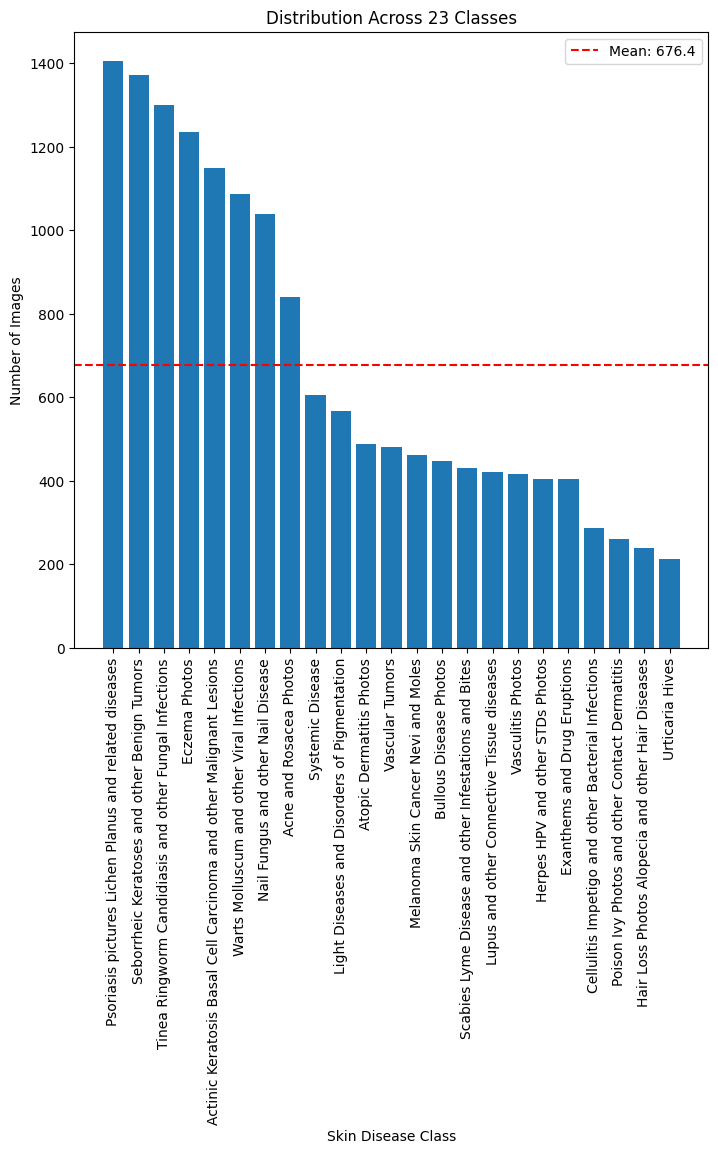

In [5]:
plt.figure(figsize=(18, 8))

# Bar plot
plt.subplot(1, 2, 1)
plt.bar(train_df['Class'], train_df['Train_Count'])
plt.xticks(rotation=90)
plt.xlabel('Skin Disease Class')
plt.ylabel('Number of Images')
plt.title(f'Distribution Across {len(train_df)} Classes')

plt.axhline(
    y=train_df['Train_Count'].mean(),
    color='red',
    linestyle='--',
    label=f"Mean: {train_df['Train_Count'].mean():.1f}"
)

plt.legend()


## Box plot

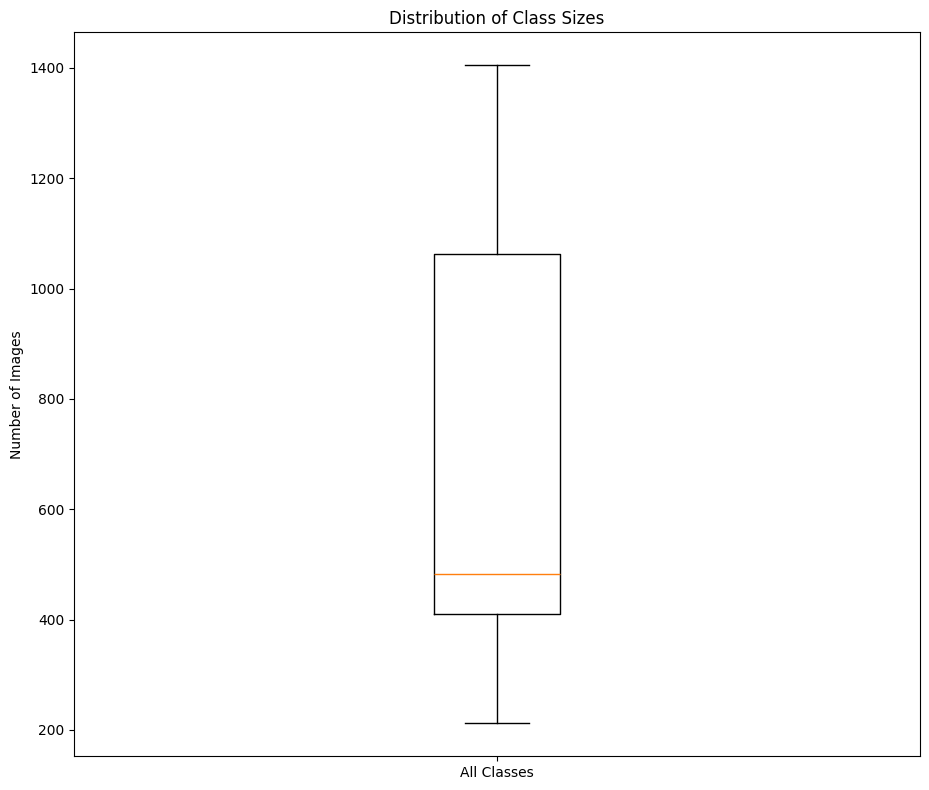

In [6]:
plt.figure(figsize=(18, 8))
plt.subplot(1, 2, 2)
plt.boxplot(train_df['Train_Count'])
plt.title('Distribution of Class Sizes')
plt.ylabel('Number of Images')
plt.xticks([1], ['All Classes'])

plt.tight_layout()
plt.show()

## Test Set Analysis 

In [7]:
# Analyze test set 
test_counts = []

for class_name in sorted(classes):  # Use same classes as train
    class_folder = os.path.join(test_path, class_name)
    
    if os.path.isdir(class_folder):
        image_files = [
            f for f in os.listdir(class_folder)
            if f.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp', '.tiff'))
        ]
        
        test_counts.append({
            "Class": class_name,
            "Test_Count": len(image_files)
        })

test_df = pd.DataFrame(test_counts)

# Merge train and test distributions
distribution_df = train_df.merge(test_df, on='Class', how='left')
distribution_df['Test_Count'] = distribution_df['Test_Count'].fillna(0).astype(int)
distribution_df['Total'] = distribution_df['Train_Count'] + distribution_df['Test_Count']

print("Train/Test Split Analysis:")
print(f"Total Train: {distribution_df['Train_Count'].sum():,}")
print(f"Total Test: {distribution_df['Test_Count'].sum():,}")
print(f"Split Ratio: {distribution_df['Test_Count'].sum()/distribution_df['Train_Count'].sum():.2%}")

# Check if any class missing from test
missing_classes = distribution_df[distribution_df['Test_Count'] == 0]
if len(missing_classes) > 0:
    print(f"\n Warning: {len(missing_classes)} classes missing from test set:")
    print(missing_classes['Class'].tolist())

Train/Test Split Analysis:
Total Train: 15,557
Total Test: 4,002
Split Ratio: 25.72%


Train/Test Split Pie Chart

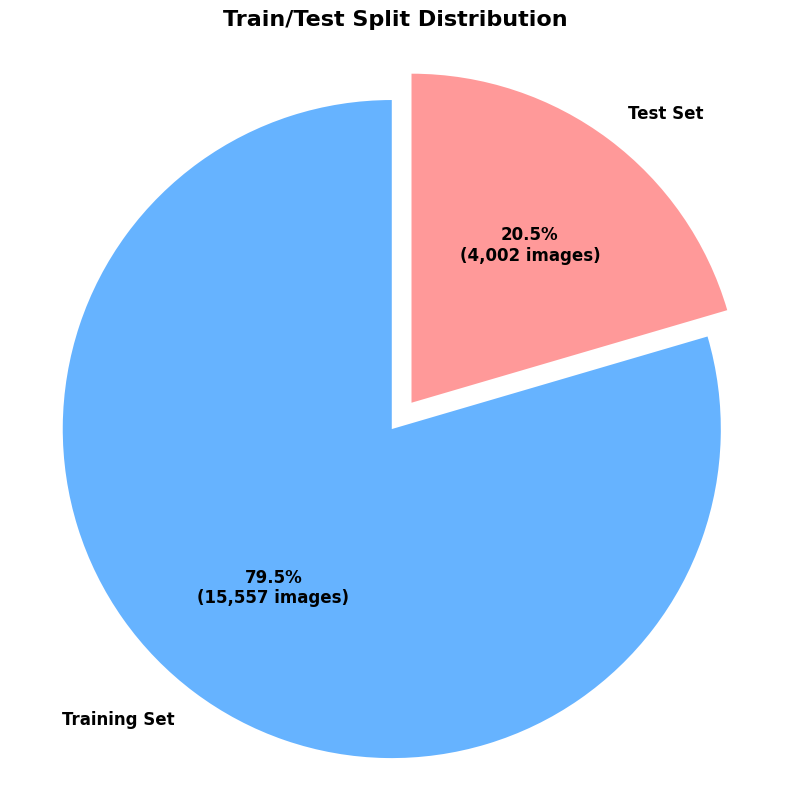

In [8]:
# Calculate totals
total_train = distribution_df['Train_Count'].sum()
total_test = distribution_df['Test_Count'].sum()
total_images = total_train + total_test

# Create pie chart
plt.figure(figsize=(8, 8))
colors = ['#66b3ff', '#ff9999']
explode = (0.05, 0.05)  # Slightly explode both slices

plt.pie([total_train, total_test], 
        labels=['Training Set', 'Test Set'],
        autopct=lambda pct: f'{pct:.1f}%\n({int(pct/100*total_images):,} images)',
        colors=colors,
        explode=explode,
        startangle=90,
        textprops={'fontsize': 12, 'weight': 'bold'})

plt.title('Train/Test Split Distribution', fontsize=16, weight='bold', pad=20)
plt.axis('equal')  # Equal aspect ratio ensures pie is circular

# Add total annotation
plt.annotate(f'Total Dataset: {total_images:,} images', 
             xy=(0, -1.2), ha='center', fontsize=12, 
             bbox=dict(boxstyle='round,pad=0.5', facecolor='lightgray', alpha=0.8))

plt.tight_layout()
plt.show()

## Calculate class imbalance metrics

In [9]:
# Calculate key statistics
largest_class = train_df['Train_Count'].max()
smallest_class = train_df['Train_Count'].min()
ratio = largest_class / smallest_class
median = train_df['Train_Count'].median()
mean = train_df['Train_Count'].mean()

print("CLASS IMBALANCE ANALYSIS")
print(f"Largest class: {largest_class} images")
print(f"Smallest class: {smallest_class} images")
print(f"Ratio (largest/smallest): {ratio:.2f}:1")
print(f"Mean class size: {mean:.1f}")
print(f"Median class size: {median:.1f}")

if ratio > 10:
    print("SEVERE IMBALANCE: Ratio > 10:1")
elif ratio > 4:
    print(" MODERATE IMBALANCE: Ratio between 4:1 and 10:1")
elif ratio > 2:
    print(" MILD IMBALANCE: Ratio between 2:1 and 4:1")
else:
    print(" WELL BALANCED: Ratio < 2:1")

CLASS IMBALANCE ANALYSIS
Largest class: 1405 images
Smallest class: 212 images
Ratio (largest/smallest): 6.63:1
Mean class size: 676.4
Median class size: 482.0
 MODERATE IMBALANCE: Ratio between 4:1 and 10:1


Imbalance Heatmap

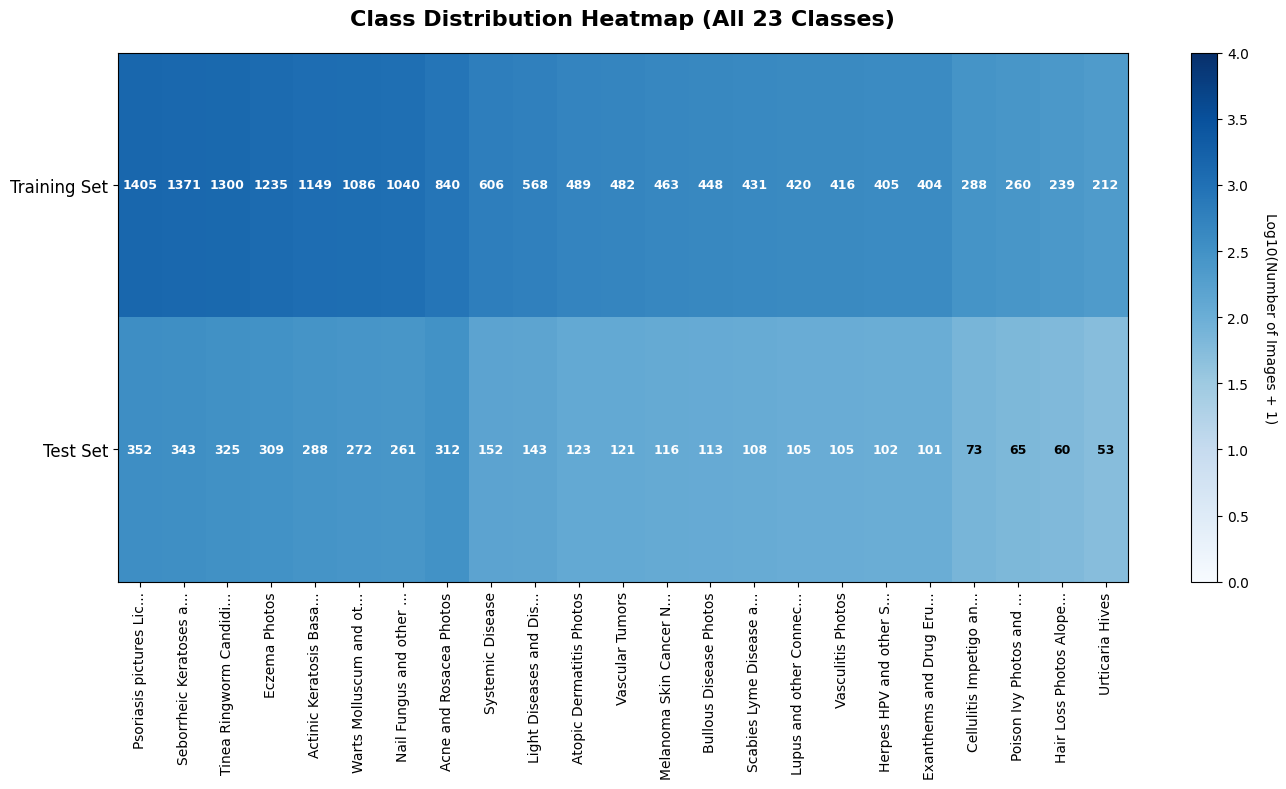

In [16]:
# Cell 6: Class Imbalance Heatmap (All Classes)
plt.figure(figsize=(14, 8))

# Sort classes by total size (largest to smallest)
sorted_df = distribution_df.sort_values('Total', ascending=False).reset_index(drop=True)

# Apply log transform (adding 1 to avoid log(0))
sorted_df['log_train'] = np.log10(sorted_df['Train_Count'] + 1)
sorted_df['log_test'] = np.log10(sorted_df['Test_Count'] + 1)

# Create heatmap data (2 rows: train and test, columns: classes)
heatmap_data = sorted_df[['log_train', 'log_test']].T

# Set column names as class names (truncate if too long)
class_labels = []
for c in sorted_df['Class']:
    if len(c) > 25:
        class_labels.append(c[:22] + '...')
    else:
        class_labels.append(c)

heatmap_data.columns = class_labels

# Plot heatmap with blue colormap
plt.imshow(heatmap_data, cmap='Blues', aspect='auto', vmin=0, vmax=4)

# Add colorbar
cbar = plt.colorbar()
cbar.set_label('Log10(Number of Images + 1)', rotation=270, labelpad=20)

# Labels
plt.yticks([0, 1], ['Training Set', 'Test Set'], fontsize=12)
plt.xticks(range(len(sorted_df)), class_labels, rotation=90, fontsize=10)
plt.title('Class Distribution Heatmap (All 23 Classes)', fontsize=16, weight='bold', pad=20)

# Add actual count annotations on the heatmap
for i in range(2):  # 0 = train, 1 = test
    for j in range(len(sorted_df)):
        if i == 0:
            value = sorted_df.iloc[j]['Train_Count']
        else:
            value = sorted_df.iloc[j]['Test_Count']
        
        # Only add text if the cell is large enough and value > 0
        if value > 0:
            color = 'white' if np.log10(value + 1) > 2 else 'black'
            plt.text(j, i, int(value), ha='center', va='center', 
                    color=color, fontsize=9, weight='bold')

plt.tight_layout()
plt.show()

## Check image integrity and collect basic stats

In [17]:
from collections import Counter

# Lists to store information
image_sizes = []
image_modes = []
corrupted_images = []

# Iterate through all classes
for class_name in classes:
    class_folder = os.path.join(train_path, class_name)
    for img_file in os.listdir(class_folder):
        img_path = os.path.join(class_folder, img_file)
        try:
            img = Image.open(img_path)
            img.verify()  # check if file is corrupted
            img = Image.open(img_path)  # reopen for size/mode
            image_sizes.append(img.size)  # (width, height)
            image_modes.append(img.mode)  # RGB, L (grayscale), etc.
        except:
            corrupted_images.append(img_path)

# Summary statistics

print("IMAGE DATASET ANALYSIS")

# Sizes
widths, heights = zip(*image_sizes)
print(f"Number of images analyzed: {len(image_sizes)}")
print(f"Image size (width x height) - min: {min(widths)}x{min(heights)}, max: {max(widths)}x{max(heights)}, mean: {int(sum(widths)/len(widths))}x{int(sum(heights)/len(heights))}")

# Color channels
mode_counts = Counter(image_modes)
print("\nImage modes (color channels):")
for mode, count in mode_counts.items():
    print(f"{mode}: {count} images")

# Corrupted images
print(f"\nNumber of corrupted/unreadable images: {len(corrupted_images)}")
if corrupted_images:
    print("Examples:", corrupted_images[:5])

IMAGE DATASET ANALYSIS
Number of images analyzed: 15557
Image size (width x height) - min: 314x359, max: 720x1128, mean: 658x544

Image modes (color channels):
RGB: 15557 images

Number of corrupted/unreadable images: 0


## File Format Analysis

In [18]:
# Analyze file formats
formats = []
for class_name in classes:
    class_folder = os.path.join(train_path, class_name)
    for img_file in os.listdir(class_folder):
        ext = os.path.splitext(img_file)[1].lower()
        formats.append(ext)

format_counts = Counter(formats)
print("\nFile Format Distribution:")
for fmt, count in format_counts.most_common():
    print(f"{fmt}: {count} images ({count/len(formats)*100:.1f}%)")



File Format Distribution:
.jpg: 15557 images (100.0%)


## Analyze image dimensions and aspect ratios

In [19]:
# Analyze sizes and aspect ratios
import numpy as np

widths, heights = zip(*image_sizes)
aspect_ratios = [w/h for w,h in image_sizes]

print(f"Width - min: {min(widths)}, max: {max(widths)}, mean: {np.mean(widths):.1f}")
print(f"Height - min: {min(heights)}, max: {max(heights)}, mean: {np.mean(heights):.1f}")
print(f"Aspect ratio - min: {min(aspect_ratios):.2f}, max: {max(aspect_ratios):.2f}, mean: {np.mean(aspect_ratios):.2f}")

Width - min: 314, max: 720, mean: 658.6
Height - min: 359, max: 1128, mean: 544.4
Aspect ratio - min: 0.44, max: 1.84, mean: 1.28


## Check color channels (RGB vs grayscale etc.)

In [20]:
# Step 3: Color channels summary
from collections import Counter

mode_counts = Counter(image_modes)
print("Image modes (color channels):")
for mode, count in mode_counts.items():
    print(f"{mode}: {count} images")

Image modes (color channels):
RGB: 15557 images


## Visualize sample images per class

In [21]:
# Visualize multiple samples per class to see variability
def show_class_samples(class_name, num_samples=4):
    class_folder = os.path.join(train_path, class_name)
    images = random.sample(os.listdir(class_folder), min(num_samples, len(os.listdir(class_folder))))
    
    fig, axes = plt.subplots(1, len(images), figsize=(15, 4))
    if len(images) == 1:
        axes = [axes]
    
    for i, img_file in enumerate(images):
        img_path = os.path.join(class_folder, img_file)
        img = Image.open(img_path)
        axes[i].imshow(img)
        axes[i].set_title(f"{img.size}\n{img.mode}", fontsize=8)
        axes[i].axis('off')
    
    plt.suptitle(f"Class: {class_name} (Total: {train_df[train_df['Class']==class_name]['Train_Count'].values[0]} images)")
    plt.tight_layout()
    plt.show()

# Show samples from smallest and largest classes
print("Samples from LARGEST class:")
show_class_samples(train_df.iloc[0]['Class'])

print("\nSamples from SMALLEST class:")
show_class_samples(train_df.iloc[-1]['Class'])

# Show samples from a medium-sized class
mid_idx = len(train_df) // 2
print("\nSamples from MEDIUM class:")
show_class_samples(train_df.iloc[mid_idx]['Class'])

Samples from LARGEST class:


NameError: name 'random' is not defined

## Distribution of image widths & heights

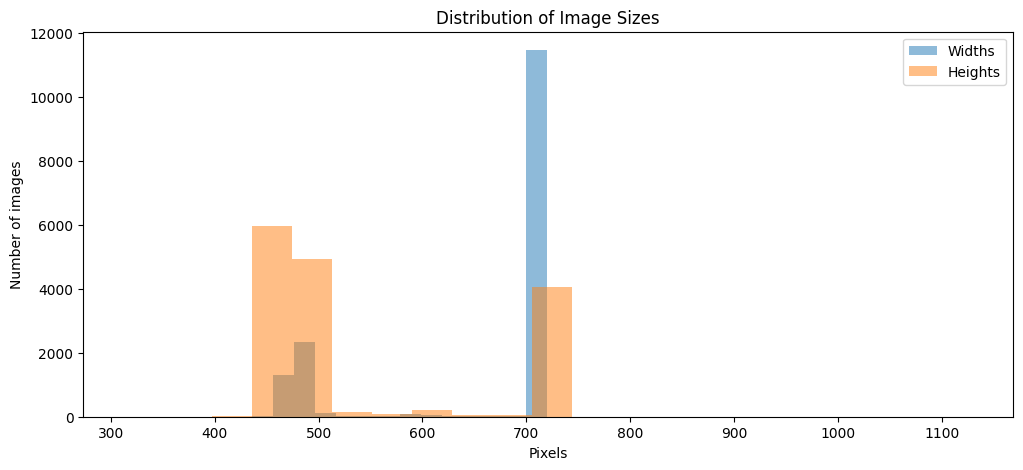

In [ ]:
plt.figure(figsize=(12,5))
plt.hist(widths, bins=20, alpha=0.5, label='Widths')
plt.hist(heights, bins=20, alpha=0.5, label='Heights')
plt.xlabel('Pixels')
plt.ylabel('Number of images')
plt.title('Distribution of Image Sizes')
plt.legend()
plt.show()

## Distribution of color modes

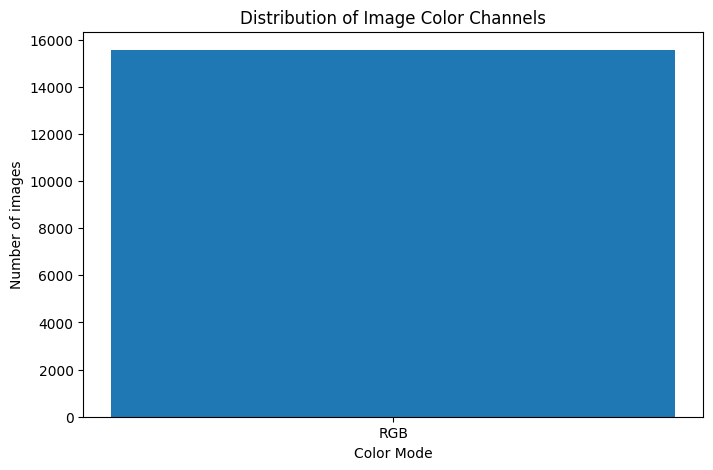

In [ ]:
plt.figure(figsize=(8,5))
plt.bar(mode_counts.keys(), mode_counts.values())
plt.xlabel('Color Mode')
plt.ylabel('Number of images')
plt.title('Distribution of Image Color Channels')
plt.show()

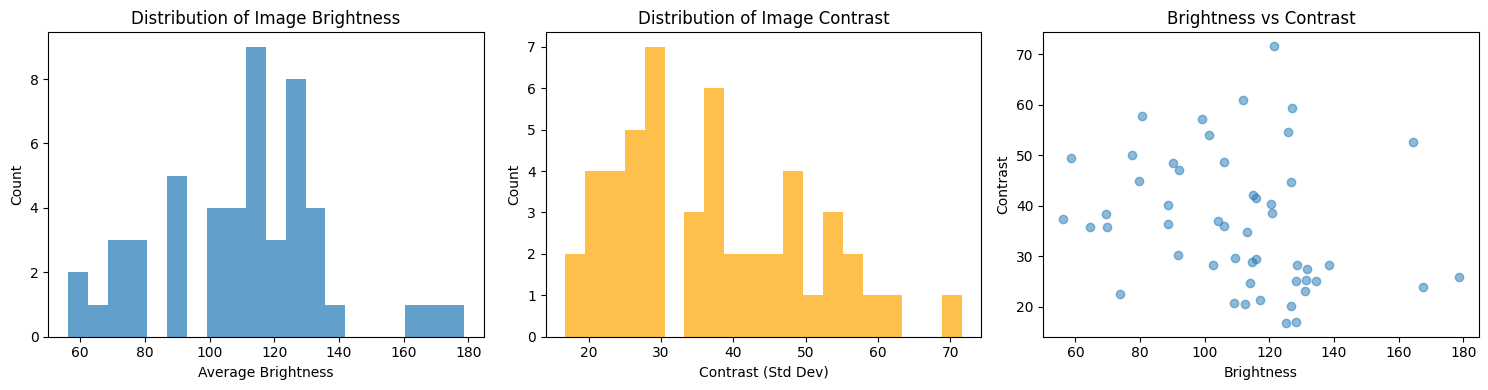

In [ ]:
# Check image statistics (brightness, contrast)
def get_image_stats(img_path):
    img = Image.open(img_path).convert('L')  # Convert to grayscale
    img_array = np.array(img)
    return {
        'mean': img_array.mean(),
        'std': img_array.std(),
        'min': img_array.min(),
        'max': img_array.max()
    }

# Sample a few images per class for quality assessment
quality_stats = []
sample_size = min(5, min(train_df['Train_Count']))  # Sample 5 per class or less

for class_name in classes[:10]:  # Limit to first 10 classes for speed
    class_folder = os.path.join(train_path, class_name)
    images = os.listdir(class_folder)[:sample_size]
    
    for img_file in images:
        img_path = os.path.join(class_folder, img_file)
        try:
            stats = get_image_stats(img_path)
            stats['class'] = class_name
            quality_stats.append(stats)
        except:
            continue

quality_df = pd.DataFrame(quality_stats)

# Plot brightness distribution
plt.figure(figsize=(15,4))

plt.subplot(1,3,1)
plt.hist(quality_df['mean'], bins=20, alpha=0.7)
plt.xlabel('Average Brightness')
plt.ylabel('Count')
plt.title('Distribution of Image Brightness')

plt.subplot(1,3,2)
plt.hist(quality_df['std'], bins=20, alpha=0.7, color='orange')
plt.xlabel('Contrast (Std Dev)')
plt.ylabel('Count')
plt.title('Distribution of Image Contrast')

plt.subplot(1,3,3)
plt.scatter(quality_df['mean'], quality_df['std'], alpha=0.5)
plt.xlabel('Brightness')
plt.ylabel('Contrast')
plt.title('Brightness vs Contrast')

plt.tight_layout()
plt.show()

## CHECKING FOR DUPLICATES IN TRAIN SET

In [ ]:
import hashlib
from collections import defaultdict

def find_duplicates_hash(directory, recursive=True):
    """
    Find duplicate images using MD5 hash (fast, but exact duplicates only)
    """
    hash_dict = defaultdict(list)
    duplicate_count = 0
    
    # Walk through directory
    for root, dirs, files in os.walk(directory):
        for file in files:
            if file.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp', '.tiff')):
                file_path = os.path.join(root, file)
                
                # Calculate MD5 hash
                with open(file_path, 'rb') as f:
                    file_hash = hashlib.md5(f.read()).hexdigest()
                
                hash_dict[file_hash].append(file_path)
    
    # Filter duplicates (hashes with more than one file)
    duplicates = {h: paths for h, paths in hash_dict.items() if len(paths) > 1}
    
    return duplicates

# Check for duplicates within train set
print("Checking for duplicates in TRAIN set...")
train_duplicates = find_duplicates_hash(train_path)

print(f"Found {len(train_duplicates)} sets of duplicate images in train set")
for hash_val, paths in list(train_duplicates.items())[:5]:  # Show first 5
    print(f"\nDuplicate set ({len(paths)} images):")
    for path in paths:
        print(f"  - {path}")

# Check for duplicates within test set
print("\n" + "="*50)
print("Checking for duplicates in TEST set...")
test_duplicates = find_duplicates_hash(test_path)

print(f"Found {len(test_duplicates)} sets of duplicate images in test set")

# Check for cross-set duplicates (train vs test) - CRITICAL!
print("\n" + "="*50)
print("Checking for duplicates ACROSS train and test sets...")

def find_cross_duplicates(dir1, dir2):
    """Find images that appear in both directories"""
    hash_dict1 = {}
    hash_dict2 = {}
    
    # Get all hashes from first directory
    for root, dirs, files in os.walk(dir1):
        for file in files:
            if file.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp', '.tiff')):
                path = os.path.join(root, file)
                with open(path, 'rb') as f:
                    file_hash = hashlib.md5(f.read()).hexdigest()
                hash_dict1[file_hash] = path
    
    # Get all hashes from second directory
    for root, dirs, files in os.walk(dir2):
        for file in files:
            if file.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp', '.tiff')):
                path = os.path.join(root, file)
                with open(path, 'rb') as f:
                    file_hash = hashlib.md5(f.read()).hexdigest()
                hash_dict2[file_hash] = path
    
    # Find common hashes
    common_hashes = set(hash_dict1.keys()) & set(hash_dict2.keys())
    
    cross_duplicates = []
    for hash_val in common_hashes:
        cross_duplicates.append({
            'hash': hash_val,
            'train_path': hash_dict1[hash_val],
            'test_path': hash_dict2[hash_val]
        })
    
    return cross_duplicates

cross_duplicates = find_cross_duplicates(train_path, test_path)

print(f"Found {len(cross_duplicates)} images that appear in BOTH train and test sets!")
if cross_duplicates:
    print("\n  CRITICAL ISSUE: Data leakage detected!")
    for dup in cross_duplicates[:5]:  # Show first 5
        print(f"  Train: {dup['train_path']}")
        print(f"  Test:  {dup['test_path']}")
        print()

Checking for duplicates in TRAIN set...
Found 632 sets of duplicate images in train set

Duplicate set (2 images):
  - c:\Users\suma\Desktop\skin-diagnosis\dermnet\train\Acne and Rosacea Photos\07Acne081101.jpg
  - c:\Users\suma\Desktop\skin-diagnosis\dermnet\train\Acne and Rosacea Photos\acne-cystic-12.jpg

Duplicate set (2 images):
  - c:\Users\suma\Desktop\skin-diagnosis\dermnet\train\Acne and Rosacea Photos\07PerioralDermq.jpg
  - c:\Users\suma\Desktop\skin-diagnosis\dermnet\train\Acne and Rosacea Photos\perioral-dermatitis-32.jpg

Duplicate set (2 images):
  - c:\Users\suma\Desktop\skin-diagnosis\dermnet\train\Acne and Rosacea Photos\07PerlecheAccutane.jpg
  - c:\Users\suma\Desktop\skin-diagnosis\dermnet\train\Acne and Rosacea Photos\acne-cystic-43.jpg

Duplicate set (2 images):
  - c:\Users\suma\Desktop\skin-diagnosis\dermnet\train\Acne and Rosacea Photos\07SteroidRosacea43.jpg
  - c:\Users\suma\Desktop\skin-diagnosis\dermnet\train\Acne and Rosacea Photos\rosacea-steroid-8.jpg

D

## Comprehensive Duplicate Report

In [ ]:
def generate_duplicate_report(train_path, test_path):
    """
    Generate a comprehensive report on duplicates
    """
  
    print("DUPLICATE IMAGES REPORT")
  
    
    # 1. Within train set
    train_dupes = find_duplicates_hash(train_path)
    total_duplicate_images_train = sum(len(paths) for paths in train_dupes.values())
    unique_duplicate_sets_train = len(train_dupes)
    
    print(f"\n TRAIN SET:")
    print(f"   - Total duplicate sets: {unique_duplicate_sets_train}")
    print(f"   - Total duplicate images: {total_duplicate_images_train}")
    if unique_duplicate_sets_train > 0:
        print(f"   - Average copies per duplicate: {total_duplicate_images_train/unique_duplicate_sets_train:.1f}")
    
    # 2. Within test set
    test_dupes = find_duplicates_hash(test_path)
    total_duplicate_images_test = sum(len(paths) for paths in test_dupes.values())
    unique_duplicate_sets_test = len(test_dupes)
    
    print(f"\n TEST SET:")
    print(f"   - Total duplicate sets: {unique_duplicate_sets_test}")
    print(f"   - Total duplicate images: {total_duplicate_images_test}")
    
    # 3. Cross-set duplicates
    cross_dupes = find_cross_duplicates(train_path, test_path)
    
    print(f"\n CROSS-SET DUPLICATES (TRAIN <-> TEST):")
    print(f"   - Images appearing in both sets: {len(cross_dupes)}")
    
    if len(cross_dupes) > 0:
        print("\n   CRITICAL: Data leakage detected!")
        print("   These images must be removed from one set!")
        
        # Show distribution across classes
        class_distribution = {}
        for dup in cross_dupes:
            # Extract class name from path
            class_name = os.path.basename(os.path.dirname(dup['train_path']))
            class_distribution[class_name] = class_distribution.get(class_name, 0) + 1
        
        print("\n   Distribution across classes:")
        for class_name, count in sorted(class_distribution.items(), key=lambda x: x[1], reverse=True)[:10]:
            print(f"     {class_name}: {count} images")
    
    # 4. Recommendations
    print("\n" + "="*60)
    print("RECOMMENDATIONS:")
    print("="*60)
    
    if len(cross_dupes) > 0:
        print(" HIGH PRIORITY: Remove cross-set duplicates")
        print("   - Keep images in train set OR test set, not both")
        print("   - Usually better to keep in train set for more training data")
    
    if unique_duplicate_sets_train > 0:
        print("\n MEDIUM PRIORITY: Consider removing duplicates within train set")
        print("   - Duplicate images can over-emphasize certain examples")
        print("   - Keep one copy per unique image")
    
    if unique_duplicate_sets_test > 0:
        print("\n LOW PRIORITY: Duplicates in test set")
        print("   - Remove duplicates for accurate evaluation metrics")
        print("   - Each unique image should appear once in test set")
    
    return {
        'train_duplicates': train_dupes,
        'test_duplicates': test_dupes,
        'cross_duplicates': cross_dupes
    }

# Run the comprehensive report
duplicate_info = generate_duplicate_report(train_path, test_path)

DUPLICATE IMAGES REPORT

 TRAIN SET:
   - Total duplicate sets: 632
   - Total duplicate images: 1296
   - Average copies per duplicate: 2.1

 TEST SET:
   - Total duplicate sets: 52
   - Total duplicate images: 104

 CROSS-SET DUPLICATES (TRAIN <-> TEST):
   - Images appearing in both sets: 541

   CRITICAL: Data leakage detected!
   These images must be removed from one set!

   Distribution across classes:
     Acne and Rosacea Photos: 266 images
     Nail Fungus and other Nail Disease: 46 images
     Eczema Photos: 45 images
     Psoriasis pictures Lichen Planus and related diseases: 29 images
     Warts Molluscum and other Viral Infections: 28 images
     Herpes HPV and other STDs Photos: 20 images
     Tinea Ringworm Candidiasis and other Fungal Infections: 20 images
     Hair Loss Photos Alopecia and other Hair Diseases: 19 images
     Actinic Keratosis Basal Cell Carcinoma and other Malignant Lesions: 15 images
     Exanthems and Drug Eruptions: 10 images

RECOMMENDATIONS:
 HIG